# 01 · Sales readiness (primary business case)

Connects to the analytics layer through **SQLAlchemy**, explores with **pandas**, and answers the sales-readiness questions: peak period, top 50 products per month, categories & regions, customer segments, sellers to prepare, and the gold-member audience.

In [1]:
import sys, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "..")            # analysis/warehouse.py
from warehouse import get_engine, query, table
engine = get_engine()               # SQLAlchemy engine: DuckDB by default, BigQuery with WAREHOUSE=bigquery
pd.set_option("display.float_format", "{:,.2f}".format)
print(engine.url)

duckdb:////home/claude/olist-data-platform/data/warehouse/olist.duckdb


## 1. Monthly sales trend

,month_start,orders,customers,total_revenue,avg_order_value,late_delivery_rate
12,2017-09-01,4227,4154,"717,102.72",169.65,0.05
0,2017-10-01,4547,4481,"764,756.03",168.19,0.05
11,2017-11-01,7423,7315,"1,172,191.68",157.91,0.14
10,2017-12-01,5620,5553,"861,526.77",153.30,0.08
13,2018-01-01,7187,7088,"1,101,920.01",153.32,0.06
3,2018-02-01,6625,6469,"979,486.16",147.85,0.16
9,2018-03-01,7168,7077,"1,152,656.99",160.81,0.21
16,2018-04-01,6919,6863,"1,156,248.89",167.11,0.05
14,2018-05-01,6833,6775,"1,145,686.46",167.67,0.08
8,2018-06-01,6145,6106,"1,020,381.90",166.05,0.01


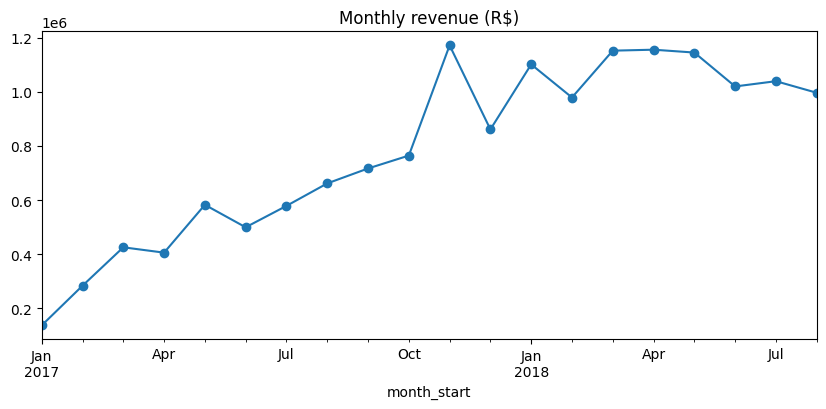

In [2]:
monthly = table("monthly_sales", engine).sort_values("month_start")
monthly = monthly[(monthly.month_start >= "2017-01-01") & (monthly.month_start <= "2018-08-01")]
ax = monthly.plot(x="month_start", y="total_revenue", marker="o", figsize=(10,4), title="Monthly revenue (R$)", legend=False)
monthly[["month_start","orders","customers","total_revenue","avg_order_value","late_delivery_rate"]].tail(12)

November 2017 (Black Friday) is the peak month; 2018 runs well above 2017 on a like-for-like basis, so the campaign is best timed around November with stock built up from September.

## 2. Top 50 products for each month

In [3]:
top = table("top_products_monthly", engine)
top = top[(top.month_start >= "2017-01-01") & (top.month_start <= "2018-08-01")]
# example: the top 10 of the peak month
top[top.month_start == "2017-11-01"].sort_values("revenue_rank").head(10)[["revenue_rank","product_id","category","units_sold","revenue"]]

,revenue_rank,product_id,category,units_sold,revenue
467,1,6a162a899a815ed15db1689e8efc976c,cool_stuff,10,"6,349.00"
468,2,dc404a1496a08f9f5540c8b5d4b92925,toys,21,"6,299.79"
469,3,c183fd5d2abf05873fa6e1014ed9e06c,agro_industry_and_commerce,6,"5,934.60"
470,4,588531f8ec37e7d5ff5b7b22ea0488f8,computers,4,"5,748.00"
471,5,422879e10f46682990de24d770e7f83d,garden_tools,91,"4,769.70"
472,6,389d119b48cf3043d311335e499d9c6b,garden_tools,87,"4,712.19"
473,7,223d34a3d9334039f5ff9511dc044bbb,telephony,18,"4,439.16"
474,8,53759a2ecddad2bb87a079a1f1519f73,garden_tools,82,"4,397.70"
475,9,431d674f9a4fbd0957ecf6ba3fcb6899,telephony,17,"4,328.90"
476,10,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,7,"4,270.00"


In [4]:
appearances = top.groupby(["product_id","category"]).size().rename("months_in_top50").reset_index().sort_values("months_in_top50", ascending=False)
print(f"{len(appearances)} distinct products ever reach a monthly top 50; {int((appearances.months_in_top50>=6).sum())} do so in 6+ months")
appearances.head(15)

635 distinct products ever reach a monthly top 50; 21 do so in 6+ months


,product_id,category,months_in_top50
281,6cdd53843498f92890544667809f1595,health_beauty,16
459,bb50f2e236e5eea0100680137654686c,health_beauty,12
375,99a4788cb24856965c36a24e339b6058,bed_bath_table,10
308,7a10781637204d8d10485c71a6108a2e,watches_gifts,10
518,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,10
165,422879e10f46682990de24d770e7f83d,garden_tools,8
553,e0d64dcfaa3b6db5c54ca298ae101d05,watches_gifts,8
611,f819f0c84a64f02d3a5606ca95edd272,watches_gifts,8
157,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,7
417,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,7


The monthly top-50 is volatile (635 distinct products), but a core of ~20 products is in the list most months — these are the 'always-stock' items.

## 3. Which categories and regions

customer_state
SP   0.38
RJ   0.13
MG   0.12
RS   0.06
PR   0.05
Name: revenue, dtype: float64

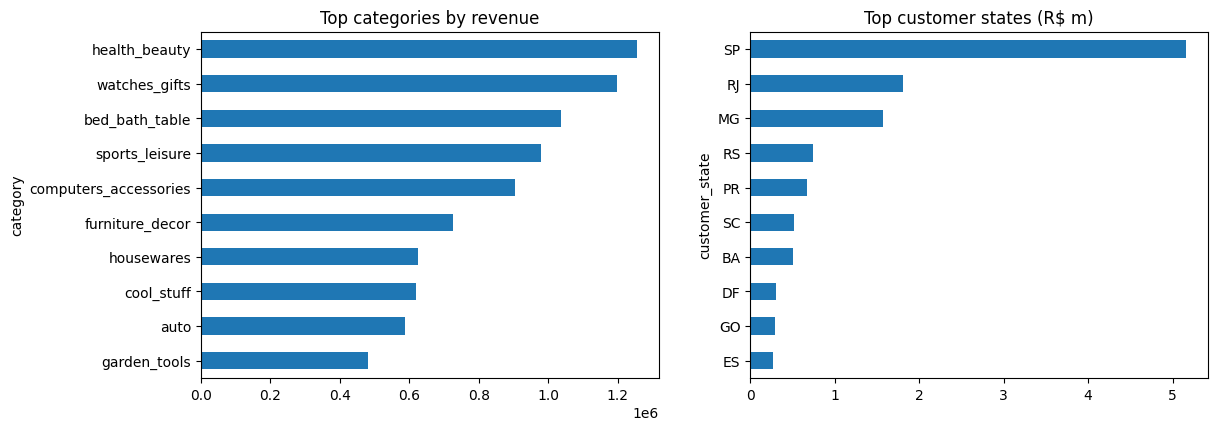

In [5]:
cr = table("category_region_sales", engine)
cat = cr.groupby("category").revenue.sum().sort_values(ascending=False)
state = cr.groupby("customer_state").revenue.sum().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cat.head(10).sort_values().plot.barh(ax=axes[0], title="Top categories by revenue")
(state.head(10)/1e6).sort_values().plot.barh(ax=axes[1], title="Top customer states (R$ m)")
(state/state.sum()).head(5)

In [6]:
pd.crosstab(cr.category, cr.customer_state, values=cr.revenue, aggfunc="sum").loc[cat.head(8).index, state.head(5).index].round(0)

customer_state,SP,RJ,MG,RS,PR
category,,,,,
health_beauty,"460,474.00","144,913.00","157,433.00","51,318.00","54,949.00"
watches_gifts,"431,119.00","183,931.00","123,474.00","48,153.00","59,859.00"
bed_bath_table,"477,794.00","147,785.00","129,487.00","60,271.00","45,571.00"
sports_leisure,"382,266.00","123,529.00","112,371.00","53,596.00","58,494.00"
computers_accessories,"347,163.00","119,962.00","109,895.00","52,758.00","43,577.00"
furniture_decor,"285,743.00","97,657.00","78,845.00","54,814.00","49,485.00"
housewares,"273,484.00","76,743.00","76,258.00","38,898.00","31,163.00"
cool_stuff,"212,337.00","82,680.00","70,186.00","44,177.00","37,539.00"


## 4. Customer segments and the gold audience

In [7]:
cm = table("customer_metrics", engine)
seg = cm.groupby("customer_segment").agg(customers=("customer_unique_id","size"), revenue=("lifetime_value","sum"), avg_ltv=("lifetime_value","mean"), avg_orders=("order_count","mean"))
seg["revenue_share"] = seg.revenue/seg.revenue.sum()
print(f"Repeat-purchase rate: {(cm.order_count>1).mean():.1%}")
seg.sort_values("revenue", ascending=False)

Repeat-purchase rate: 3.0%


,customers,revenue,avg_ltv,avg_orders,revenue_share
customer_segment,,,,,
silver,23959,"4,844,115.79",202.18,1.04,0.31
gold,12082,"4,742,024.21",392.49,1.10,0.30
lapsed,23146,"3,738,717.95",161.53,1.00,0.24
standard,34939,"2,216,389.54",63.44,1.00,0.14
repeat,864,"194,279.55",224.86,2.06,0.01


In [8]:
gold_cats = query('''
select p.category, sum(f.price) as revenue, count(distinct m.customer_unique_id) as gold_customers
from olist_analytics.fact_order_items f
join olist_analytics.dim_customers c  on f.customer_id = c.customer_id
join olist_analytics.customer_metrics m on c.customer_unique_id = m.customer_unique_id
join olist_analytics.dim_products p    on f.product_id = p.product_id
where m.customer_segment = 'gold'
group by 1 order by 2 desc limit 10''', engine)
gold_cats

,category,revenue,gold_customers
0,watches_gifts,"478,465.68",1283
1,health_beauty,"470,727.69",1330
2,sports_leisure,"271,912.74",921
3,bed_bath_table,"238,162.36",959
4,computers_accessories,"237,484.69",871
5,housewares,"221,997.64",814
6,auto,"216,596.56",624
7,furniture_decor,"194,582.87",837
8,baby,"153,887.66",390
9,cool_stuff,"148,937.67",554


Gold members are ~13% of customers but ~30% of revenue, concentrated in SP/RJ/MG and over-indexing on watches & gifts and health & beauty. That is the target audience and the assortment for the campaign.

## 5. Sellers to prepare for stronger demand

In [9]:
sp = table("seller_performance", engine).dropna(subset=["revenue"]).sort_values("revenue", ascending=False)
sp["cum_share"] = sp.revenue.cumsum()/sp.revenue.sum()
print(f"{int((sp.cum_share<=0.8).sum()+1)} of {len(sp)} sellers generate 80% of revenue")
sp.head(15)[["seller_id","seller_state","orders","revenue","avg_seller_handling_days","late_rate","avg_review_score"]]

540 of 3053 sellers generate 80% of revenue


,seller_id,seller_state,orders,revenue,avg_seller_handling_days,late_rate,avg_review_score
1217,4869f7a5dfa277a7dca6462dcf3b52b2,SP,"1,131.00","229,237.63",2.27,0.12,4.14
2117,53243585a1d6dc2643021fd1853d8905,BA,358.00,"222,776.05",2.94,0.04,4.13
1654,4a3ca9315b744ce9f8e9374361493884,SP,"1,804.00","200,326.12",2.23,0.11,3.83
1412,fa1c13f2614d7b5c4749cbc52fecda94,SP,584.00,"192,842.13",2.21,0.10,4.37
872,7c67e1448b00f6e969d365cea6b010ab,SP,982.00,"187,923.89",11.49,0.10,3.35
640,7e93a43ef30c4f03f38b393420bc753a,SP,332.00,"172,583.88",2.29,0.06,4.36
1432,da8622b14eb17ae2831f4ac5b9dab84a,SP,"1,314.00","160,236.57",2.20,0.07,4.07
236,7a67c85e85bb2ce8582c35f2203ad736,SP,"1,159.00","141,715.54",1.47,0.06,4.27
205,1025f0e2d44d7041d6cf58b6550e0bfa,SP,915.00,"138,968.55",3.65,0.09,3.86
810,955fee9216a65b617aa5c0531780ce60,SP,"1,286.00","135,159.70",1.55,0.08,4.09
